# Food Nutrition — Descriptive Statistics & Calorie Correlations

Dataset: `FOOD-DATA-GROUP1.csv` — 551 foods described by 34 nutritional variables.

1. Descriptive statistics for every numeric variable.
2. Correlation between `Caloric Value` and each nutritional component.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e6e6",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
})

# Diverging poles, reused by every figure so the colors mean the same thing throughout.
POS, NEG, NEUTRAL = "#b2182b", "#2166ac", "#8a8a8a"

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("FOOD-DATA-GROUP1.csv")

# Two leftover export artifacts: both are just the row number.
df = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0"])

nutrients = df.columns.drop("food")
df.head()

,food,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats,Polyunsaturated Fats,Carbohydrates,Sugars,Protein,Dietary Fiber,Cholesterol,Sodium,Water,Vitamin A,Vitamin B1,Vitamin B11,Vitamin B12,Vitamin B2,Vitamin B3,Vitamin B5,Vitamin B6,Vitamin C,Vitamin D,Vitamin E,Vitamin K,Calcium,Copper,Iron,Magnesium,Manganese,Phosphorus,Potassium,Selenium,Zinc,Nutrition Density
0,cream cheese,51,5.000,2.900,1.300,0.200,0.800,0.500,0.900,0.000,14.600,0.016,7.600,0.200,0.033,0.064,0.092,0.097,0.084,0.052,0.096,0.004,0.000,0.000,0.100,0.008,14.100,0.082,0.027,1.300,0.091,15.500,19.100,0.039,7.070
1,neufchatel cheese,215,19.400,10.900,4.900,0.800,3.100,2.700,7.800,0.000,62.900,0.300,53.600,0.200,0.099,0.079,0.090,0.100,0.200,0.500,0.078,0.000,0.000,0.300,0.045,99.500,0.034,0.100,8.500,0.088,117.300,129.200,0.054,0.700,130.100
2,requeijao cremoso light catupiry,49,3.600,2.300,0.900,0.000,0.900,3.400,0.800,0.100,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.400
3,ricotta cheese,30,2.000,1.300,0.500,0.002,1.500,0.091,1.500,0.000,9.800,0.017,14.700,0.075,0.019,0.079,0.091,0.027,0.041,0.016,0.007,0.006,0.000,0.001,0.011,0.097,41.200,0.097,0.096,4.000,0.024,30.800,43.800,0.035,5.196
4,cream cheese low fat,30,2.300,1.400,0.600,0.042,1.200,0.900,1.200,0.000,8.100,0.046,10.000,0.016,0.080,0.062,0.049,0.026,0.080,0.100,0.003,0.000,0.036,0.009,0.019,22.200,0.072,0.008,1.200,0.098,22.800,37.100,0.034,0.053,27.007


### Data Dictionary

To provide context for the analysis, the nutritional meaning of 5 key variables within the dataset is described below:

* **Caloric Value:** Represents the total amount of energy provided by a food serving, measured in kilocalories (kcal). It is our main target variable for understanding which nutrients drive the energy value.
* **Fat:** Indicates the total amount of lipids (fats) present in the serving. Nutritionally, it is the most energy-dense macronutrient, providing approximately 9 kcal per gram.
* **Protein:** Quantifies the grams of protein per serving. It is an essential macronutrient for cellular building and repair, and provides approximately 4 kcal per gram (similar to carbohydrates).
* **Water:** Measures the water content in the food serving. Although it does not provide calories, it drastically influences the product's weight and its caloric density (foods with high water content are usually less caloric per serving).
* **Nutrition Density:** A calculated index that attempts to summarize the overall nutritional quality of the food.

## Data quality

In [7]:
print(f"foods (rows):            {df.shape[0]}")
print(f"Original Columns CSV: {df.shape[1] + 2}")
print(f"Final Columns:        {df.shape[1]}")
print(f"numeric variables:       {len(nutrients)}")
print(f"missing values:          {int(df.isna().sum().sum())}")
print(f"duplicate food names:    {int(df['food'].duplicated().sum())}")
print(f"non-numeric columns:     {list(df.dtypes[df.dtypes == object].index)}")

foods (rows):            551
Original Columns CSV: 37
Final Columns:        35
numeric variables:       34
missing values:          0
duplicate food names:    0
non-numeric columns:     []


### Data Types


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 551 entries, 0 to 550
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   food                  551 non-null    str    
 1   Caloric Value         551 non-null    int64  
 2   Fat                   551 non-null    float64
 3   Saturated Fats        551 non-null    float64
 4   Monounsaturated Fats  551 non-null    float64
 5   Polyunsaturated Fats  551 non-null    float64
 6   Carbohydrates         551 non-null    float64
 7   Sugars                551 non-null    float64
 8   Protein               551 non-null    float64
 9   Dietary Fiber         551 non-null    float64
 10  Cholesterol           551 non-null    float64
 11  Sodium                551 non-null    float64
 12  Water                 551 non-null    float64
 13  Vitamin A             551 non-null    float64
 14  Vitamin B1            551 non-null    float64
 15  Vitamin B11           551 non-null

In [5]:
pd.DataFrame(df.dtypes, columns=["Tipo de dato"])

,Tipo de dato
food,str
Caloric Value,int64
Fat,float64
Saturated Fats,float64
Monounsaturated Fats,float64
Polyunsaturated Fats,float64
Carbohydrates,float64
Sugars,float64
Protein,float64
Dietary Fiber,float64


## Descriptive statistics

`describe()` plus the shape measures that matter for skewed nutritional data: the median
(robust against the long right tail),the mode, the IQR, the coefficient of variation (`CV`, spread
relative to the mean — comparable across variables on wildly different units), skew,
kurtosis, and the share of exact zeros (many micronutrients are absent from most foods).

In [8]:
stats = df[nutrients].describe().T
stats["median"] = df[nutrients].median()
stats["mode"] = df[nutrients].mode().iloc[0]
stats["IQR"] = stats["75%"] - stats["25%"]
stats["CV"] = stats["std"] / stats["mean"]
stats["skew"] = df[nutrients].skew()
stats["kurtosis"] = df[nutrients].kurtosis()
stats["zeros %"] = (df[nutrients] == 0).mean() * 100

stats[["count", "mean", "std", "min", "25%", "median", "mode", "75%", "max",
       "IQR", "CV", "skew", "kurtosis", "zeros %"]]

,count,mean,std,min,25%,median,mode,75%,max,IQR,CV,skew,kurtosis,zeros %
Caloric Value,551.000,237.359,199.236,3.000,94.500,186.000,186.000,337.000,"1,578.000",242.500,0.839,1.928,6.834,0.000
Fat,551.000,10.767,12.544,0.000,2.500,6.600,0.200,14.400,87.500,11.900,1.165,2.323,7.106,0.726
Saturated Fats,551.000,3.723,5.397,0.000,0.500,1.800,0.200,4.800,43.500,4.300,1.450,3.438,17.140,3.085
Monounsaturated Fats,551.000,4.002,5.541,0.000,0.600,2.200,0.000,5.150,48.000,4.550,1.385,3.217,14.812,3.448
Polyunsaturated Fats,551.000,2.171,3.471,0.000,0.400,1.100,0.300,2.600,40.100,2.200,1.599,5.283,44.887,4.174
Carbohydrates,551.000,15.819,20.289,0.000,0.000,5.100,0.000,28.700,128.300,28.700,1.283,1.634,3.742,30.309
Sugars,551.000,2.709,7.456,0.000,0.000,0.000,0.000,2.200,70.800,2.200,2.752,5.543,36.741,56.624
Protein,551.000,18.418,18.932,0.000,5.300,11.900,4.600,25.650,86.900,20.350,1.028,1.726,2.695,1.452
Dietary Fiber,551.000,1.098,2.157,0.000,0.000,0.000,0.000,1.500,17.500,1.500,1.964,3.125,13.233,60.436
Cholesterol,551.000,61.591,70.143,0.000,9.750,33.900,0.000,82.650,352.500,72.900,1.139,1.527,1.795,11.978


Distribution of the target variable:

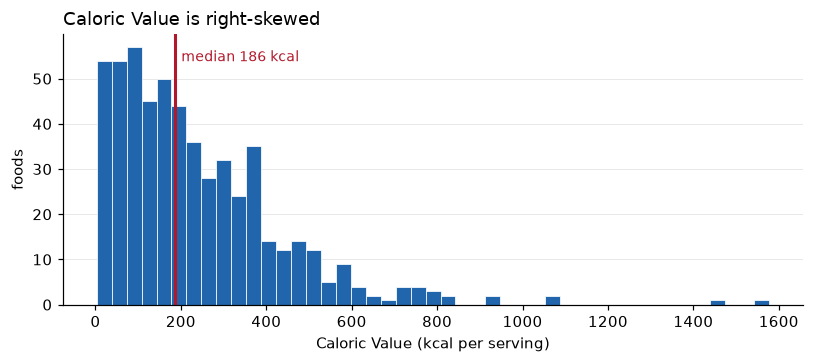

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.hist(df["Caloric Value"], bins=45, color=NEG, edgecolor="white", linewidth=0.5)
ax.axvline(df["Caloric Value"].median(), color=POS, lw=2)
ax.text(df["Caloric Value"].median() + 15, ax.get_ylim()[1] * 0.9,
        f"median {df['Caloric Value'].median():.0f} kcal", color=POS, fontsize=9)
ax.set_xlabel("Caloric Value (kcal per serving)")
ax.set_ylabel("foods")
ax.set_title("Caloric Value is right-skewed", loc="left")
ax.grid(axis="x", visible=False)
plt.tight_layout()

## Correlation of each component with Caloric Value

Pearson `r` between `Caloric Value` and every other variable, ranked.

In [6]:
corr_matrix = df[nutrients].corr()
cal_corr = corr_matrix["Caloric Value"].drop("Caloric Value").sort_values(ascending=False)
cal_corr.to_frame("r vs Caloric Value")

,r vs Caloric Value
Fat,0.909
Polyunsaturated Fats,0.759
Monounsaturated Fats,0.704
Saturated Fats,0.665
Carbohydrates,0.625
Protein,0.599
Phosphorus,0.549
Nutrition Density,0.543
Cholesterol,0.537
Potassium,0.524


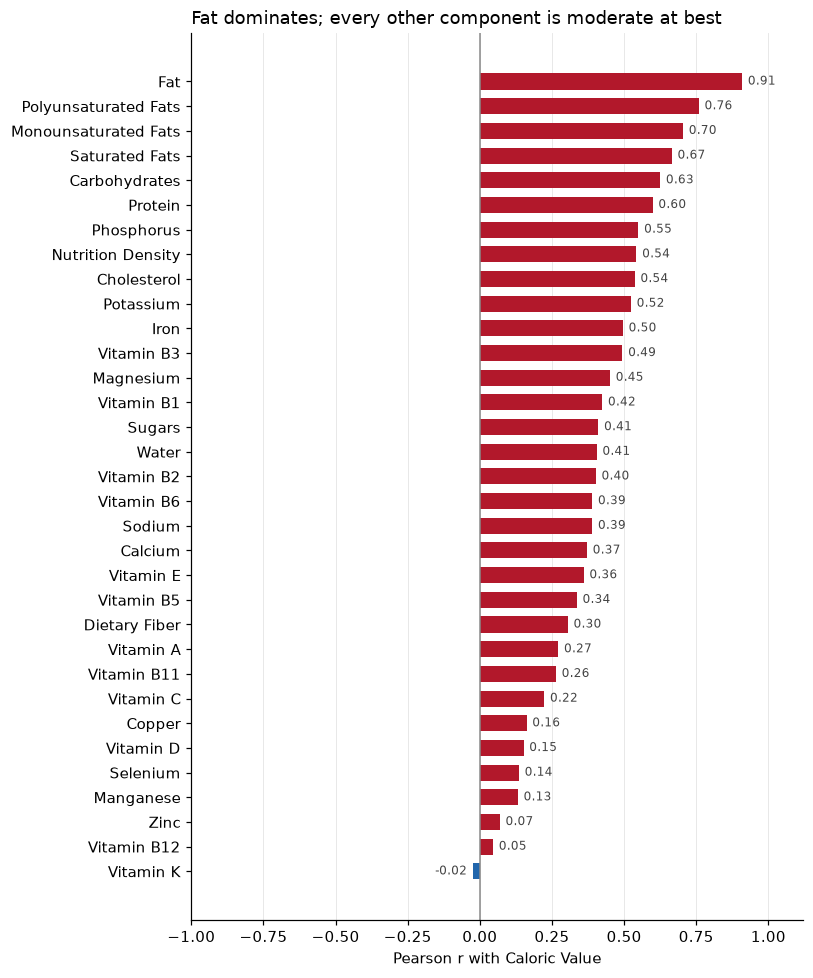

In [7]:
order = cal_corr.sort_values()

fig, ax = plt.subplots(figsize=(7.5, 9))
ax.barh(order.index, order.values, color=[POS if v >= 0 else NEG for v in order], height=0.65)
ax.axvline(0, color=NEUTRAL, lw=1)
ax.set_xlim(-1, 1.12)
ax.set_xlabel("Pearson r with Caloric Value")
ax.set_title("Fat dominates; every other component is moderate at best", loc="left")
ax.grid(axis="y", visible=False)

for name, v in order.items():
    ax.text(v + (0.02 if v >= 0 else -0.02), name, f"{v:.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8, color="#444")

plt.tight_layout()

## Full correlation matrix

Diverging scale centered at zero: red = positive, blue = negative, white = no linear relationship.

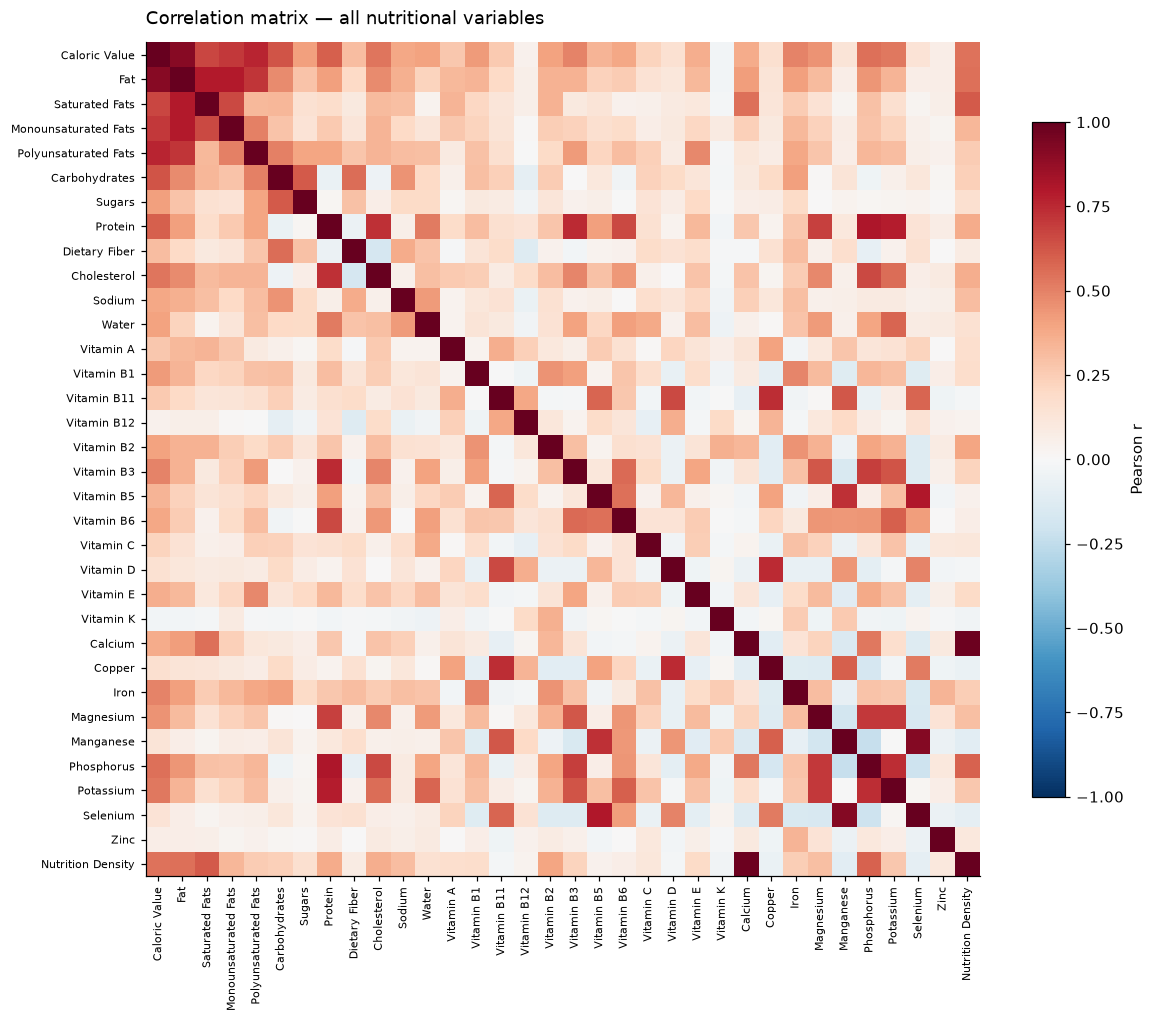

In [8]:
fig, ax = plt.subplots(figsize=(11, 9.5))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(nutrients)), nutrients, rotation=90, fontsize=7)
ax.set_yticks(range(len(nutrients)), nutrients, fontsize=7)
ax.grid(False)
ax.set_title("Correlation matrix — all nutritional variables", loc="left", pad=12)

cb = fig.colorbar(im, ax=ax, shrink=0.75)
cb.set_label("Pearson r")
plt.tight_layout()

## Reading the results

**Fat is the single strongest driver of calories** (r = 0.91). The fat subtypes follow
(polyunsaturated 0.76, monounsaturated 0.70, saturated 0.67) because they are components of
`Fat` itself, not independent signals. Carbohydrates (0.63) and Protein (0.60) come next —
consistent with the fact that these three macronutrients are the only ones that carry energy.
Only `Vitamin K` is (negligibly) negative at r = -0.02, i.e. no linear relationship at all.

**Three caveats that change how the rest of the table should be read:**

1. **Rows are per serving, not per 100 g.** Serving mass ranges from ~1.6 g to ~636 g
   (median ~132 g). Serving size therefore inflates *every* variable at once, which is why
   `Water` shows r = 0.41 despite contributing zero calories: bigger portions simply contain
   more of everything. Most of the mid-table micronutrient correlations (potassium, iron,
   magnesium…) are picking up portion size rather than a nutritional relationship. To measure
   composition instead of portion, normalize each row to a fixed mass before correlating.

2. **Calories are near-deterministic, not merely correlated.** The Atwater formula
   `9·Fat + 4·Carbohydrates + 4·Protein` reproduces `Caloric Value` at r = 0.9955 with a
   median absolute error of ~2 kcal. `Caloric Value` is essentially a computed column. Any
   model predicting it from these three features will look near-perfect for arithmetic
   reasons — that is not a finding about food.

3. **`Nutrition Density` looks unreliable.** Its correlation with `Calcium` is 0.98 — the
   strongest pair anywhere in the matrix, ahead of even Fat ↔ Caloric Value. A nutrition
   density score should not be an almost exact restatement of one mineral, so this column
   is best treated as suspect (or excluded) until its definition is confirmed.

Two other pairs stand out in the matrix and are worth a look before any modeling:
`Selenium ↔ Manganese` (0.91) and `Phosphorus ↔ Protein` (0.81).